In [25]:
import os
import json
import re
from functools import lru_cache
from datetime import datetime
from urllib.parse import urlparse
from typing import TypedDict, Optional ,Literal ,Any

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from groq import Groq
from ddgs import DDGS
from dateutil import parser as date_parser
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from pathlib import Path

RESEARCH_STORE_DIR = Path("research_store")
PIPELINE_VERSION = "v1.1"

In [2]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY", "").strip()
if not GROQ_API_KEY:
    raise RuntimeError("Set GROQ_API_KEY")

client = Groq(api_key=GROQ_API_KEY)

In [3]:
MAX_ARTICLES = 30
TOP_K = 10
DDG_RESULTS_PER_QUERY = 3
PREVIEW_CHARS = 280
LLM_MODEL = "openai/gpt-oss-120b"

In [4]:
# =============== SCHEMAS =================

class Article(BaseModel):
    """
    Lightweight preview object.
    `content` is intentionally short (DDG snippet or truncated preview),
    not full article text.
    """
    title: str
    url: str
    source: str
    published_date: str
    content: str
    relevance_score: float | None = None


class ArticleAnalysis(BaseModel):
    title: str
    summary: str
    stock_impact: str
    sentiment: str
    importance_score: int = Field(ge=1, le=10)
    reasoning: str


class RankedArticle(BaseModel):
    title: str
    url: str
    source: str
    published_date: str
    content: str
    decision_value_score: float = Field(ge=0.0, le=10.0)
    recency_score: float = Field(ge=0.0, le=10.0)
    impact_score: float = Field(ge=0.0, le=10.0)
    novelty_score: float = Field(ge=0.0, le=10.0)
    evidence_score: float = Field(ge=0.0, le=10.0)
    reasoning: str


class ResearchSummary(BaseModel):
    company: str
    overall_sentiment: str
    positive_catalysts: list[str]
    negative_catalysts: list[str]
    key_risks: list[str]
    opportunities: list[str]
    final_reasoning: str

In [26]:
# ========= STATE =========

class ResearchState(TypedDict):
    query: str
    resolved_company: Optional[str]
    all_articles: list[Article]
    top_articles: list[RankedArticle]
    articles_analyzed: list[ArticleAnalysis]
    research_summary: Optional[ResearchSummary]
    
    # repo / human-in-loop fields
    repo_hit: bool
    repo_action: Literal["reuse", "refresh", "cancel"]
    repo_company_dir: str
    repo_latest_path: str
    cached_research: dict[str, Any]


In [6]:
# =============== HELPERS ===============

def _truncate(text: str, limit: int = PREVIEW_CHARS) -> str:
    text = (text or "").strip()
    if len(text) <= limit:
        return text
    return text[:limit].rstrip() + "..."


def _normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", (text or "").strip().lower())


def _strip_code_fences(raw: str) -> str:
    raw = (raw or "").strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.IGNORECASE | re.DOTALL)
        raw = re.sub(r"\s*```$", "", raw, flags=re.DOTALL)
    return raw.strip()


def _extract_json(raw: str):
    raw = _strip_code_fences(raw)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        # fallback: try to isolate the first JSON array/object
        obj_match = re.search(r"\{.*\}", raw, flags=re.DOTALL)
        arr_match = re.search(r"\[.*\]", raw, flags=re.DOTALL)
        candidate = None
        if obj_match:
            candidate = obj_match.group(0)
        elif arr_match:
            candidate = arr_match.group(0)
        if candidate is None:
            raise
        return json.loads(candidate)

In [27]:
def _company_slug(company: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", (company or "").lower()).strip("_")
    return slug or "unknown"


def _company_dir(company: str) -> Path:
    return RESEARCH_STORE_DIR / _company_slug(company)


def _latest_path(company: str) -> Path:
    return _company_dir(company) / "latest.json"


def _history_path(company: str, date_str: str) -> Path:
    return _company_dir(company) / "history" / f"{date_str}.json"


def _to_jsonable(obj):
    if obj is None:
        return None
    if isinstance(obj, BaseModel):
        return obj.model_dump()
    if isinstance(obj, list):
        return [_to_jsonable(x) for x in obj]
    if isinstance(obj, dict):
        return {k: _to_jsonable(v) for k, v in obj.items()}
    return obj


def _load_research_file(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def _write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False, default=str)

In [7]:
def _safe_company_name(data) -> str:
    if isinstance(data, dict):
        company = (data.get("company") or "").strip()
        return company
    if isinstance(data, str):
        return data.strip()
    return ""


def _flatten_llm_list_response(data) -> list[str]:
    if isinstance(data, list):
        return [str(x).strip() for x in data if str(x).strip()]
    if isinstance(data, dict):
        # allow {"queries":[...]} as a backup
        vals = data.get("queries")
        if isinstance(vals, list):
            return [str(x).strip() for x in vals if str(x).strip()]
    return []

In [8]:
# =============== LLMs ===============

summary_llm = ChatGroq(
    model=LLM_MODEL,
    temperature=0.1,
)

In [9]:
def _resolve_company_from_query(query: str) -> str:
    prompt = f"""
You are resolving the company mentioned in a financial research query.

Return ONLY a JSON object like:
{{"company":"Microsoft"}}

Rules:
- Map symbols, founder names, products, projects, or company nicknames to the company.
- Return the most likely company.
- Do not explain.
- Do not return markdown.

User query: {query}
"""
    resp = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
    )

    raw = resp.choices[0].message.content.strip()
    data = _extract_json(raw)
    company = _safe_company_name(data)

    if not company:
        raise ValueError(f"Could not resolve company from query: {query}")

    return company


def resolve_entity_node(state: ResearchState) -> ResearchState:
    query = (state.get("query") or "").strip()
    if not query:
        raise ValueError("state['query'] is empty.")

    company = _resolve_company_from_query(query)
    state["resolved_company"] = company
    return state


In [10]:
def _generate_search_queries(query: str, company: str) -> list[str]:
    search_prompts = [
        query,
        f"{company} latest news",
        f"{company} earnings",
        f"{company} AI developments",
        f"{company} regulation",
        f"{company} lawsuit",
        f"{company} probe",
        f"{company} partnerships",
        f"{company} acquisitions",
        f"{company} product launch",
    ]

    llm_prompt = f"""
You are helping build search queries for a financial research agent.

Given the user query below, generate 6 short web search queries.

Rules:
- Focus on the resolved company and likely relevant subtopics.
- Prefer real company-moving topics: earnings, guidance, regulation, lawsuits, products, strategy, partnerships, acquisitions, AI, management.
- Avoid vague queries.
- Return ONLY a JSON array of strings.
- No markdown, no explanation.

User query: {query}
Resolved company: {company}
"""
    try:
        resp = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": "You generate focused financial search queries."},
                {"role": "user", "content": llm_prompt},
            ],
            temperature=0.1,
        )
        raw = resp.choices[0].message.content.strip()
        llm_queries = _flatten_llm_list_response(_extract_json(raw))
        search_prompts.extend(llm_queries)
    except Exception as e:
        print(f"[research_articles] LLM query generation failed, using fallback queries only: {e}")

    seen = set()
    queries = []
    for q in search_prompts:
        q = q.strip()
        if q and q.lower() not in seen:
            seen.add(q.lower())
            queries.append(q)
    return queries

In [11]:
def research_articles(state: ResearchState) -> ResearchState:
    query = (state.get("query") or "").strip()
    company = (state.get("resolved_company") or "").strip()

    if not query:
        raise ValueError("state['query'] is empty in research_articles().")
    if not company:
        raise ValueError("state['resolved_company'] is empty in research_articles().")

    queries = _generate_search_queries(query, company)

    results = []
    with DDGS() as ddgs:
        for q in queries:
            try:
                news_results = list(ddgs.news(q, max_results=DDG_RESULTS_PER_QUERY))
                if not news_results:
                    news_results = list(ddgs.text(q, max_results=DDG_RESULTS_PER_QUERY, safesearch="moderate"))

                for r in news_results:
                    title = (r.get("title") or "").strip()
                    url = (r.get("href") or r.get("url") or "").strip()
                    body = (r.get("body") or r.get("snippet") or "").strip()
                    source = urlparse(url).netloc.replace("www.", "") if url else "duckduckgo"

                    if not title or not url:
                        continue

                    published_date = r.get("date") or datetime.utcnow().date().isoformat()

                    results.append({
                        "title": title,
                        "url": url,
                        "source": source or "duckduckgo",
                        "published_date": published_date,
                        # keep only a compact preview, not long stored text
                        "content": _truncate(body if body else title, PREVIEW_CHARS),
                        "relevance_score": None,
                    })

            except Exception as e:
                print(f"[research_articles] DDG search failed for query='{q}': {e}")
                continue

    deduped = []
    seen_urls = set()
    seen_titles = set()

    for item in results:
        u = item["url"].rstrip("/").lower()
        t = item["title"].lower()

        if u in seen_urls or t in seen_titles:
            continue

        seen_urls.add(u)
        seen_titles.add(t)
        deduped.append(Article(**item))

        if len(deduped) >= MAX_ARTICLES:
            break

    state["all_articles"] = deduped

    if not deduped:
        raise ValueError(
            f"No articles found for query='{query}', company='{company}'. Used queries: {queries}"
        )

    return state

In [12]:
@lru_cache(maxsize=4096)
def _score_recency(published_date: str) -> float:
    try:
        dt = date_parser.parse(published_date)
        days_old = (datetime.utcnow() - dt.replace(tzinfo=None)).days
        if days_old <= 1:
            return 10.0
        if days_old <= 3:
            return 9.0
        if days_old <= 7:
            return 8.0
        if days_old <= 14:
            return 7.0
        if days_old <= 30:
            return 6.0
        if days_old <= 90:
            return 4.0
        return 2.0
    except Exception:
        return 3.0


In [13]:
def _score_impact(article: Article, company: str) -> tuple[float, list[str]]:
    text = _normalize_text(f"{article.title} {article.content}")
    company = _normalize_text(company)
    reasons = []
    score = 3.0

    high_impact_keywords = [
        "earnings", "guidance", "forecast", "capex", "investment",
        "regulation", "antitrust", "lawsuit", "probe", "investigation",
        "acquisition", "merger", "partnership", "launch", "product",
        "debut", "restructuring", "layoff", "ceo", "management", "margin",
        "revenue", "profit", "free cash flow", "openai", "ai chip", "data center"
    ]

    if company in text:
        score += 1.5
        reasons.append("direct company mention")

    for kw in high_impact_keywords:
        if kw in text:
            score += 0.6
            reasons.append(f"keyword:{kw}")

    if any(x in text for x in ["earnings", "guidance", "forecast"]):
        score += 1.0
        reasons.append("earnings/guidance content")

    if any(x in text for x in ["regulation", "antitrust", "lawsuit", "probe", "investigation"]):
        score += 1.2
        reasons.append("regulatory/legal impact")

    if any(x in text for x in ["acquisition", "merger", "partnership"]):
        score += 0.9
        reasons.append("strategic event")

    if any(x in text for x in ["launch", "product", "platform", "model", "infrastructure"]):
        score += 0.7
        reasons.append("product/strategy development")

    return min(score, 10.0), reasons

In [14]:
def _score_novelty(article: Article, seen_titles: set[str], seen_urls: set[str]) -> float:
    title = _normalize_text(article.title)
    url = (article.url or "").rstrip("/").lower()

    if url in seen_urls:
        return 1.0
    if title in seen_titles:
        return 2.0
    return 8.0

In [15]:
def _score_evidence(article: Article) -> float:
    text = _normalize_text(f"{article.title} {article.content}")
    score = 4.0

    evidence_keywords = [
        "reported", "announced", "filed", "sec", "earnings",
        "guidance", "revenue", "profit", "margin", "cash flow",
        "capex", "contract", "deal", "launch", "official", "ceo",
        "board", "filing", "regulator", "court"
    ]

    if any(kw in text for kw in evidence_keywords):
        score += 2.0

    if any(kw in text for kw in ["analysis", "opinion", "commentary", "view"]):
        score -= 1.5

    if len(article.content or "") > 220:
        score += 0.5
    elif len(article.content or "") < 120:
        score -= 0.5

    return max(0.0, min(score, 10.0))

In [16]:
def rank_articles(state: ResearchState) -> ResearchState:
    articles = state.get("all_articles") or []

    if not articles:
        print("[rank_articles] No articles in state['all_articles']; skipping ranking.")
        state["top_articles"] = []
        return state

    company = (state.get("resolved_company") or "").strip()
    if not company:
        raise ValueError("state['resolved_company'] is empty. Resolve entity first.")

    weighted_articles: list[RankedArticle] = []
    seen_titles: set[str] = set()
    seen_urls: set[str] = set()

    w_recency = 0.25
    w_impact = 0.40
    w_novelty = 0.15
    w_evidence = 0.20

    for idx, article in enumerate(articles, start=1):
        try:
            recency_score = _score_recency(article.published_date)
            impact_score, impact_reasons = _score_impact(article, company)
            novelty_score = _score_novelty(article, seen_titles, seen_urls)
            evidence_score = _score_evidence(article)

            decision_value_score = round(
                (
                    w_recency * recency_score
                    + w_impact * impact_score
                    + w_novelty * novelty_score
                    + w_evidence * evidence_score
                ),
                2,
            )

            reasoning_parts = [
                f"recency={recency_score:.1f}/10",
                f"impact={impact_score:.1f}/10",
                f"novelty={novelty_score:.1f}/10",
                f"evidence={evidence_score:.1f}/10",
            ]

            if impact_reasons:
                reasoning_parts.append("impact_signals=" + ", ".join(impact_reasons[:5]))

            weighted_articles.append(
                RankedArticle(
                    title=article.title,
                    url=article.url,
                    source=article.source,
                    published_date=article.published_date,
                    content=article.content,
                    decision_value_score=decision_value_score,
                    recency_score=round(recency_score, 2),
                    impact_score=round(impact_score, 2),
                    novelty_score=round(novelty_score, 2),
                    evidence_score=round(evidence_score, 2),
                    reasoning=" | ".join(reasoning_parts),
                )
            )

            seen_titles.add(_normalize_text(article.title))
            seen_urls.add((article.url or "").rstrip("/").lower())

        except Exception as e:
            print(f"[rank_articles] Skipping article #{idx} due to error: {e}")
            continue

    if not weighted_articles:
        print("[rank_articles] No articles could be ranked successfully.")
        state["top_articles"] = []
        return state

    weighted_articles.sort(key=lambda x: x.decision_value_score, reverse=True)
    state["top_articles"] = weighted_articles[:TOP_K]
    return state

In [17]:
def analyze_articles(state: ResearchState) -> ResearchState:
    """
    Single LLM call for the top-K articles.
    This replaces per-article summarization.
    """
    top_articles = state.get("top_articles") or []
    company = (state.get("resolved_company") or "").strip()

    if not top_articles:
        state["articles_analyzed"] = []
        return state

    prompt_items = []
    for i, art in enumerate(top_articles, start=1):
        prompt_items.append(
            f"""
{i}. TITLE: {art.title}
   SOURCE: {art.source}
   DATE: {art.published_date}
   PREVIEW: {art.content}
   RANK REASONING: {art.reasoning}
""".strip()
        )

    prompt = f"""
You are a financial analyst.

Analyze each article for {company} and return ONLY valid JSON.

Requirements:
- Return a JSON array.
- One object per input article.
- Preserve the title exactly.
- Keep summaries concise but factual.
- Use the following schema for each object:
  {{
    "title": "...",
    "summary": "...",
    "stock_impact": "...",
    "sentiment": "positive|negative|neutral",
    "importance_score": 1-10,
    "reasoning": "..."
  }}

Articles:
{chr(10).join(prompt_items)}
"""

    try:
        resp = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
        )
        raw = resp.choices[0].message.content.strip()
        data = _extract_json(raw)

        if not isinstance(data, list):
            raise ValueError("Article analysis LLM did not return a JSON list.")

        analyses: list[ArticleAnalysis] = []
        for item in data:
            if not isinstance(item, dict):
                continue
            try:
                analyses.append(ArticleAnalysis(**item))
            except Exception as e:
                print(f"[analyze_articles] Skipping invalid analysis item: {e}")

        # Fallback to deterministic minimal analysis if the model misses items.
        if len(analyses) < len(top_articles):
            seen_titles = {a.title for a in analyses}
            for art in top_articles:
                if art.title in seen_titles:
                    continue
                analyses.append(
                    ArticleAnalysis(
                        title=art.title,
                        summary=art.content[:180],
                        stock_impact="Potentially relevant to the investment thesis.",
                        sentiment="neutral",
                        importance_score=max(1, min(10, int(round(art.decision_value_score)))),
                        reasoning=art.reasoning,
                    )
                )

        state["articles_analyzed"] = analyses[:TOP_K]
        return state

    except Exception as e:
        print(f"[analyze_articles] LLM analysis failed, using fallback: {e}")
        state["articles_analyzed"] = [
            ArticleAnalysis(
                title=art.title,
                summary=art.content[:180],
                stock_impact="Potentially relevant to the investment thesis.",
                sentiment="neutral",
                importance_score=max(1, min(10, int(round(art.decision_value_score)))),
                reasoning=art.reasoning,
            )
            for art in top_articles
        ]
        return state

In [18]:
def build_research_summary(state: ResearchState) -> ResearchState:
    company = (state.get("resolved_company") or "").strip()
    analyses = state.get("articles_analyzed") or []

    if not analyses:
        state["research_summary"] = ResearchSummary(
            company=company or "Unknown",
            overall_sentiment="neutral",
            positive_catalysts=[],
            negative_catalysts=[],
            key_risks=[],
            opportunities=[],
            final_reasoning="No sufficiently strong articles were available for synthesis.",
        )
        return state

    prompt_items = []
    for i, a in enumerate(analyses, start=1):
        prompt_items.append(
            f"""
{i}. TITLE: {a.title}
   SUMMARY: {a.summary}
   STOCK IMPACT: {a.stock_impact}
   SENTIMENT: {a.sentiment}
   IMPORTANCE: {a.importance_score}
   REASONING: {a.reasoning}
""".strip()
        )

    prompt = f"""
You are a portfolio analyst.

Synthesize the article analyses for {company}.
Return ONLY valid JSON matching this schema:
{{
  "company": "{company}",
  "overall_sentiment": "positive|negative|neutral",
  "positive_catalysts": ["..."],
  "negative_catalysts": ["..."],
  "key_risks": ["..."],
  "opportunities": ["..."],
  "final_reasoning": "..."
}}

Analyses:
{chr(10).join(prompt_items)}
"""

    try:
        resp = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
        )
        raw = resp.choices[0].message.content.strip()
        data = _extract_json(raw)
        state["research_summary"] = ResearchSummary(**data)
        return state

    except Exception as e:
        print(f"[build_research_summary] LLM synthesis failed, using fallback: {e}")
        positive = [a.title for a in analyses if a.sentiment == "positive"][:5]
        negative = [a.title for a in analyses if a.sentiment == "negative"][:5]
        state["research_summary"] = ResearchSummary(
            company=company or "Unknown",
            overall_sentiment="neutral",
            positive_catalysts=positive,
            negative_catalysts=negative,
            key_risks=negative[:3],
            opportunities=positive[:3],
            final_reasoning="Synthesized from ranked article analyses with a deterministic fallback because the final LLM synthesis failed.",
        )
        return state

In [28]:
def check_research_repo(state: ResearchState) -> ResearchState:
    company = (state.get("resolved_company") or "").strip()
    if not company:
        raise ValueError("resolved_company is required before repo check.")

    company_dir = _company_dir(company)
    latest = _latest_path(company)

    state["repo_company_dir"] = str(company_dir)
    state["repo_latest_path"] = str(latest)

    if not latest.exists():
        state["repo_hit"] = False
        state["repo_action"] = "refresh"
        return state

    cached = _load_research_file(latest)
    state["repo_hit"] = True
    state["cached_research"] = cached

    last_updated = cached.get("last_updated", "unknown")
    print(f"\n[repo] Previous research found for {company}")
    print(f"[repo] Last updated: {last_updated}")

    choice = input(
        "Reuse previous research? [r=reuse / f=refresh / c=cancel]: "
    ).strip().lower()

    if choice in {"r", "reuse", "y", "yes", "view"}:
        state["repo_action"] = "reuse"

        # load cached state into graph state and exit early
        state["all_articles"] = [Article(**x) for x in cached.get("all_articles", [])]
        state["top_articles"] = [RankedArticle(**x) for x in cached.get("top_articles", [])]
        state["articles_analyzed"] = [
            ArticleAnalysis(**x) for x in cached.get("articles_analyzed", [])
        ]

        rs = cached.get("research_summary")
        state["research_summary"] = ResearchSummary(**rs) if rs else None
        return state

    if choice in {"c", "cancel", "n", "no"}:
        state["repo_action"] = "cancel"
        return state

    state["repo_action"] = "refresh"
    return state

In [29]:
def save_research(state: ResearchState) -> ResearchState:
    company = (state.get("resolved_company") or "").strip()
    if not company:
        raise ValueError("resolved_company is required before saving research.")

    latest = _latest_path(company)
    history_dir = _company_dir(company) / "history"
    today = datetime.utcnow().date().isoformat()
    history_file = _history_path(company, today)

    payload = {
        "company": company,
        "query": state.get("query"),
        "last_updated": datetime.utcnow().isoformat() + "Z",
        "pipeline_version": PIPELINE_VERSION,
        "repo_path": str(latest),
        "metrics": {
            "articles_fetched": len(state.get("all_articles") or []),
            "articles_ranked": len(state.get("top_articles") or []),
            "articles_analyzed": len(state.get("articles_analyzed") or []),
        },
        "all_articles": _to_jsonable(state.get("all_articles") or []),
        "top_articles": _to_jsonable(state.get("top_articles") or []),
        "articles_analyzed": _to_jsonable(state.get("articles_analyzed") or []),
        "research_summary": _to_jsonable(state.get("research_summary")),
    }

    _write_json(latest, payload)
    _write_json(history_file, payload)

    print(f"[repo] Saved latest -> {latest}")
    print(f"[repo] Saved history -> {history_file}")

    return state

In [30]:
def route_after_repo_check(state: ResearchState):
    action = state.get("repo_action", "refresh")
    if action == "reuse":
        return END
    if action == "cancel":
        return END
    return "research-articles-node"

In [31]:
graph = StateGraph(ResearchState)
graph.add_node("resolve-entity-node", resolve_entity_node)
graph.add_node("check-research-repo-node", check_research_repo)
graph.add_node("research-articles-node", research_articles)
graph.add_node("articles-ranking-node", rank_articles)
graph.add_node("analyze-articles-node", analyze_articles)
graph.add_node("build-summary-node", build_research_summary)
graph.add_node("save-research-node", save_research)


graph.add_edge(START, "resolve-entity-node")
graph.add_edge("resolve-entity-node", "check-research-repo-node")
graph.add_conditional_edges(
    "check-research-repo-node",
    route_after_repo_check,
    {
        "research-articles-node": "research-articles-node",
        END: END,
    },
)
graph.add_edge("research-articles-node", "articles-ranking-node")
graph.add_edge("articles-ranking-node", "analyze-articles-node")
graph.add_edge("analyze-articles-node", "build-summary-node")
graph.add_edge("build-summary-node", "save-research-node")
graph.add_edge("save-research-node", END)

In [32]:
workflow = graph.compile()


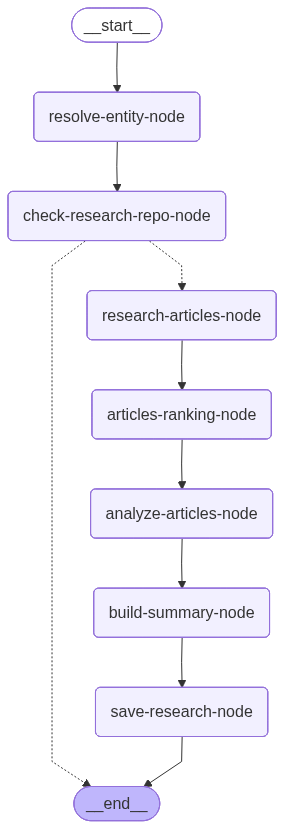

In [33]:
workflow

In [ ]:
query = "current S"
initial_state = {
    "query": query
}
result = workflow.invoke(initial_state)


[repo] Previous research found for Apple
[repo] Last updated: 2026-06-27T15:14:55.645049Z
[research_articles] DDG search failed for query='current Apple scenario in the tech ,their new deals or decisions which can affect its stock market?': No results found.
[research_articles] DDG search failed for query='Apple AI partnership deals 2024 stock implications': No results found.
[research_articles] DDG search failed for query='Apple executive leadership changes 2024 investor outlook': No results found.


C:\Users\Muskan Kirti\AppData\Local\Temp\ipykernel_15400\1763134376.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  days_old = (datetime.utcnow() - dt.replace(tzinfo=None)).days


[repo] Saved latest -> research_store\apple\latest.json
[repo] Saved history -> research_store\apple\history\2026-06-27.json


C:\Users\Muskan Kirti\AppData\Local\Temp\ipykernel_15400\3957203557.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow().date().isoformat()
C:\Users\Muskan Kirti\AppData\Local\Temp\ipykernel_15400\3957203557.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "last_updated": datetime.utcnow().isoformat() + "Z",


In [24]:
result['research_summary']

ResearchSummary(company='Apple', overall_sentiment='positive', positive_catalysts=['Broad 2027 product pipeline (new devices, CEO succession shaping roadmap)', 'Touchscreen MacBook with new form factor, Apple Silicon and keyboard', 'Potential entry into smart‑ring wearables (iRing) expanding health‑tech ecosystem', 'Maintaining price points on a subset of products, reassuring price‑sensitive customers', 'Prime Day promotional discounts driving short‑term sales momentum', 'iPhone 18 and 18e RAM upgrade and A20 AI‑centric chip reinforcing AI leadership'], negative_catalysts=['Price hikes on select iPads and MacBooks due to rising AI chip costs, which could suppress demand'], key_risks=['Higher pricing may erode demand in price‑sensitive segments', 'Reliance on speculative product rumors that may not materialize on schedule', 'Supply‑chain pressure from Apple’s massive memory orders causing component shortages and cost inflation', 'Execution risk for new form‑factor devices (e.g., touchsc